### Data analysis of actin flow data 

- Obtain the numerical value for compression rate 
- Obtain the numerical value for the actin depletion zone depth 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
filename = '../data/actin_data/kymo_wt.npz'
data = np.load(filename)
print(data.files)

['x', 't', 'v', 'v_mean', 'dvdx', 'dvdx_mean', 'dvdx_plus_dvdy_mean', 'qxx', 'qxx_mean']


In [13]:
x = data['x']
t = data['t']
dvdx = data['dvdx']

print(x.shape) 
print(t.shape) 

print(dvdx.shape)

(1024,)
(62,)
(9, 62, 1024)


extreme values of dvdx in units of (actin turnover time)^-1:
-0.12 +- 0.054 0.27 +- 0.09


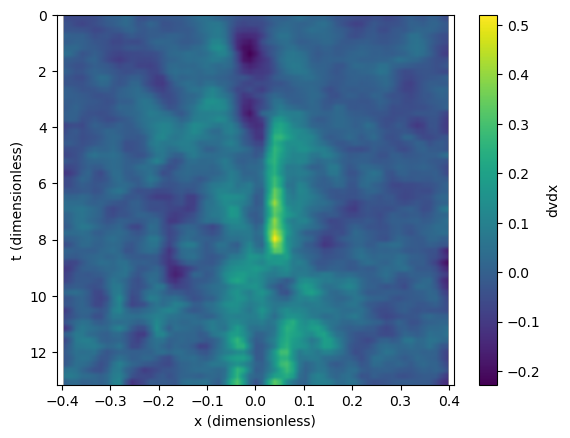

extreme values of dvdx in units of (actin turnover time)^-1:
-0.11 +- 0.045 0.25 +- 0.096


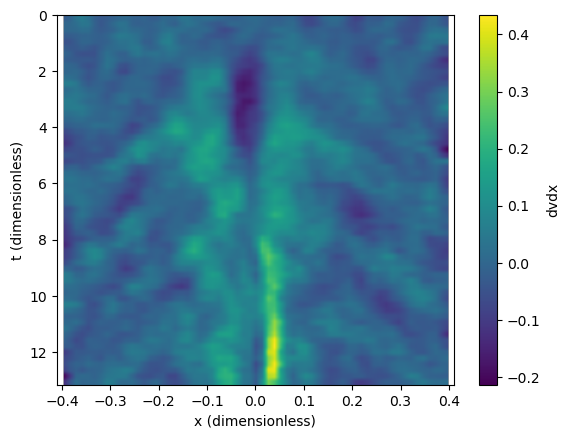

extreme values of dvdx in units of (actin turnover time)^-1:
-0.11 +- 0.047 0.1 +- 0.024


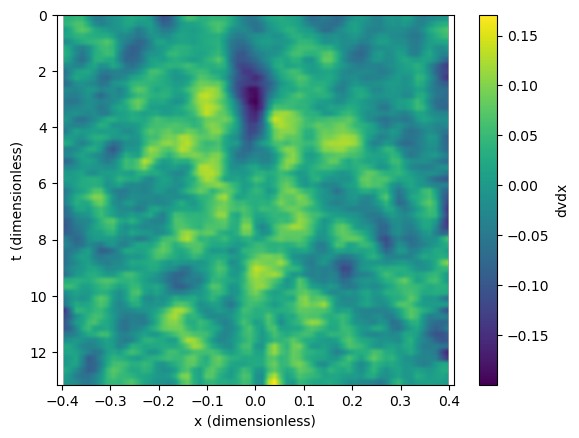

extreme values of dvdx in units of (actin turnover time)^-1:
-0.14 +- 0.073 0.21 +- 0.059


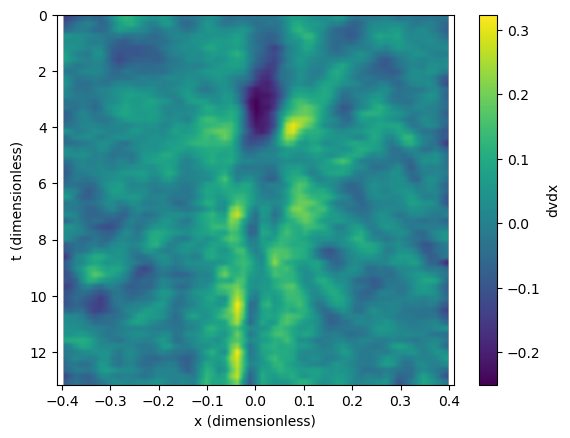

extreme values of dvdx in units of (actin turnover time)^-1:
-0.081 +- 0.034 0.23 +- 0.11


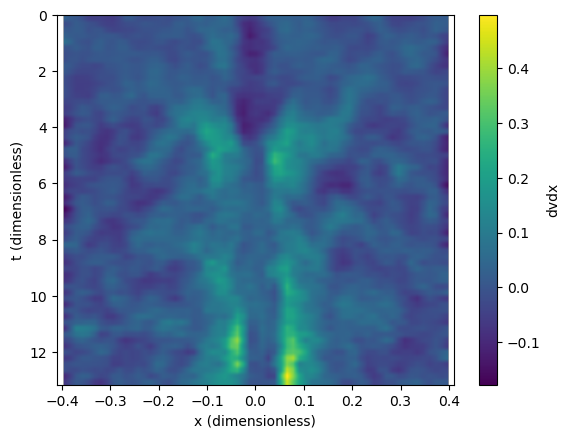

extreme values of dvdx in units of (actin turnover time)^-1:
-0.12 +- 0.1 0.36 +- 0.13


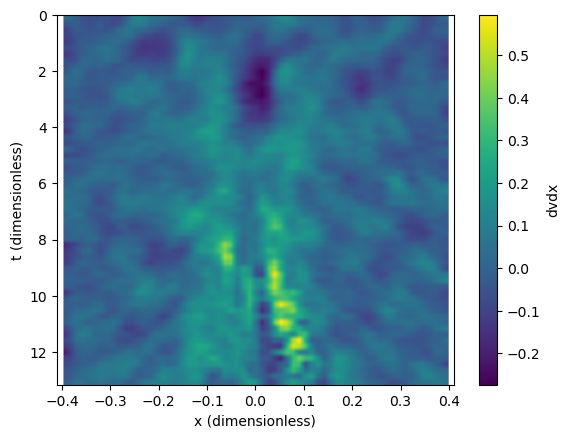

extreme values of dvdx in units of (actin turnover time)^-1:
-0.14 +- 0.078 0.36 +- 0.11


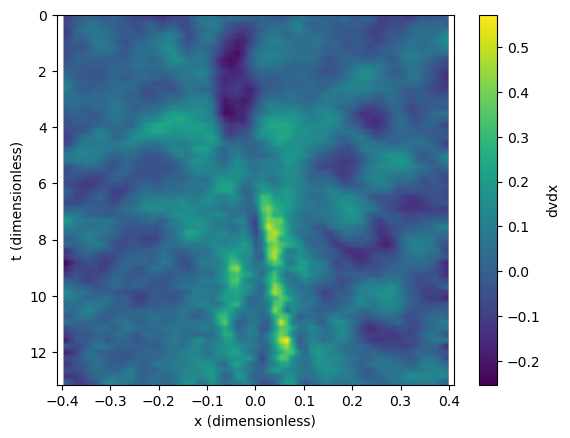

extreme values of dvdx in units of (actin turnover time)^-1:
-0.13 +- 0.058 0.26 +- 0.12


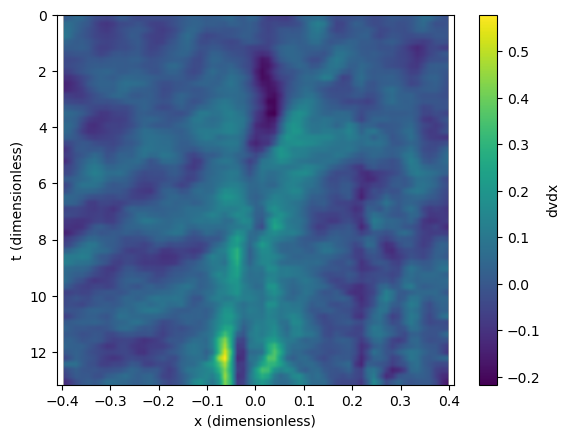

extreme values of dvdx in units of (actin turnover time)^-1:
-0.095 +- 0.045 0.25 +- 0.052


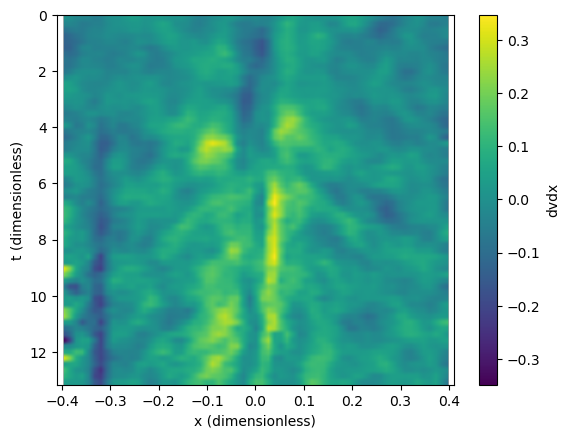

In [30]:
x_extent = x.max()/(135) # convert to units of hydrodynamic length (~100 micrometers)
t_rescaled = (t-t.min())*(60/25/1) # rescale time to units of actin turnover time (25s)
t_extent = t_rescaled.max() # convert from mins to units of actin turnover time (25s) 

dvdx_rescaled = dvdx / (60/25/1) # rescale dvdx to units of actin turnover time (25s)

mins = [] 
maxs = [] 

inward_mask = (t_rescaled<5)
outward_mask = t_rescaled>5
x_mask = (x > -0.1 * 135) & (x < 0.1 * 135)
x_shape = int(x_mask.sum())
inward_mask_2d = inward_mask[:, None] & x_mask[None, :]
outward_mask_2d = outward_mask[:, None] & x_mask[None, :]

for i in range(dvdx_rescaled.shape[0]):
    comp = dvdx_rescaled[i]

    print('extreme values of dvdx in units of (actin turnover time)^-1:')
    box_inward = comp[inward_mask_2d].reshape((-1, x_shape))
    dvdx_inward = np.nanmin(box_inward, axis=-1)

    box_outward = comp[outward_mask_2d].reshape((-1, x_shape))
    dvdx_outward = np.nanmax(box_outward, axis=-1)

    print(f'{np.mean(dvdx_inward):.2g} +- {np.std(dvdx_inward):.2g}', f'{np.mean(dvdx_outward):.2g} +- {np.std(dvdx_outward):.2g}')
    mins.append(dvdx_inward)
    maxs.append(dvdx_outward)

    plt.imshow(comp, aspect='auto', origin='upper', extent=[-x_extent, x_extent, t_extent, 0])
    plt.xlabel('x (dimensionless)')
    plt.ylabel('t (dimensionless)')
    plt.colorbar(label='dvdx')
    plt.show()


mean inward dvdx: 0.12 +- 0.066
mean outward dvdx: -0.25 +- 0.12


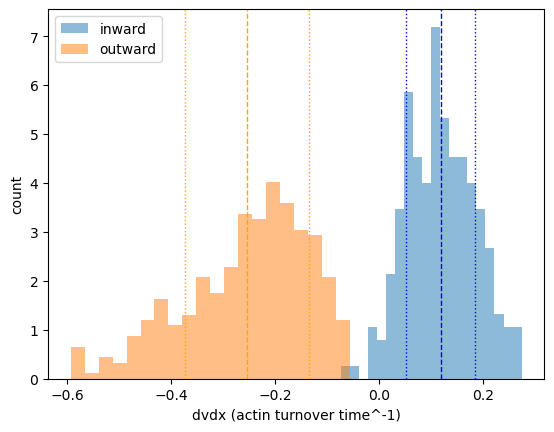

In [32]:
mins_array = - np.concatenate(mins)
maxs_array = - np.concatenate(maxs)

mean_inward = np.mean(mins_array)
std_inward = np.std(mins_array)

print(f'mean inward dvdx: {mean_inward:.2g} +- {std_inward:.2g}')
mean_outward = np.mean(maxs_array)
std_outward = np.std(maxs_array)
print(f'mean outward dvdx: {mean_outward:.2g} +- {std_outward:.2g}')

plt.hist(mins_array, bins=20, alpha=0.5, label='inward', density=True)
plt.axvline(mean_inward, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(mean_inward + std_inward, color='blue', linestyle='dotted', linewidth=1)
plt.axvline(mean_inward - std_inward, color='blue', linestyle='dotted', linewidth=1)
plt.hist(maxs_array, bins=20, alpha=0.5, label='outward', density=True)
plt.axvline(mean_outward, color='orange', linestyle='dashed', linewidth=1)
plt.axvline(mean_outward + std_outward, color='orange', linestyle='dotted', linewidth=1)
plt.axvline(mean_outward - std_outward, color='orange', linestyle='dotted', linewidth=1)
plt.xlabel('dvdx (actin turnover time^-1)')
plt.ylabel('count')
plt.legend()
plt.show()

In [23]:
filename = '../data/actin_data/line_plot-wt-lifeact_intensity_position.npy'
x, lifeact_intensity = np.load(filename)
print(lifeact_intensity.shape)

(1024,)


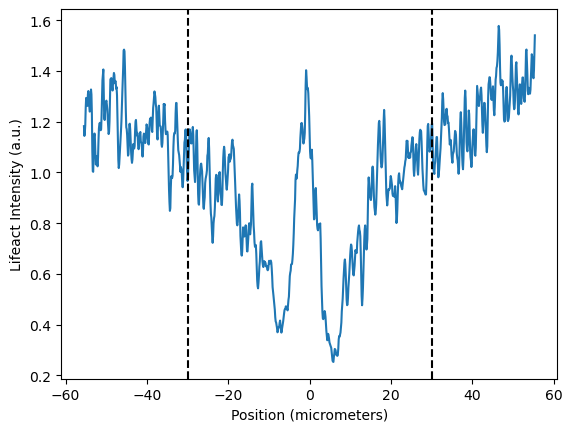

left min: 0.37, right min: 0.25
average density in the furrow: 0.31
error in average density in the furrow: 0.06
average density in the bulk: 1.2
relative depletion in the furrow: 0.3
error in relative depletion in the furrow: 0.06


In [67]:
plt.plot(x, lifeact_intensity)
plt.axvline(30, color='k', linestyle='--')
plt.axvline(-30, color='k', linestyle='--')
plt.xlabel('Position (micrometers)')
plt.ylabel('Lifeact Intensity (a.u.)')
plt.show()

left_min = np.nanmin(lifeact_intensity[x < 0])
right_min = np.nanmin(lifeact_intensity[x > 0])
print('left min: {:.2g}, right min: {:.2g}'.format(left_min, right_min))
furrow_mean = (left_min + right_min)/2
print('average density in the furrow: {:.2g}'.format(furrow_mean))
furrow_error = np.nanstd([left_min, right_min])
print('error in average density in the furrow: {:.1g}'.format(furrow_error))

bulk_mean = np.nanmean(lifeact_intensity[(x < -30) | (x > 30)])
bulk_std = np.nanstd(lifeact_intensity[(x < -30) | (x > 30)]) 

print('average density in the bulk: {:.2g}'.format(bulk_mean))

ratio = furrow_mean / bulk_mean

print('relative depletion in the furrow: {:.1g}'.format(ratio))
print('error in relative depletion in the furrow: {:.1g}'.format(ratio*np.sqrt((furrow_error/furrow_mean)**2 + (bulk_std/bulk_mean)**2)))